In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# 1. Load the Wine dataset
wine = load_wine()
X = wine.data          # 13 features (high dimensional data)
y = wine.target       # class labels
feature_names = wine.feature_names

In [3]:
# Convert to DataFrame (optional, for readability)
df = pd.DataFrame(X, columns=feature_names)

In [4]:
# 2. Standardize the data (important before PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
# 3. Apply PCA (keep all components first to check variance)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

In [6]:
# 4. Display proportion of variance captured by each component
explained_variance = pca_full.explained_variance_ratio_

In [7]:
print("Explained Variance Ratio for each Principal Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

Explained Variance Ratio for each Principal Component:
PC1: 0.3620
PC2: 0.1921
PC3: 0.1112
PC4: 0.0707
PC5: 0.0656
PC6: 0.0494
PC7: 0.0424
PC8: 0.0268
PC9: 0.0222
PC10: 0.0193
PC11: 0.0174
PC12: 0.0130
PC13: 0.0080


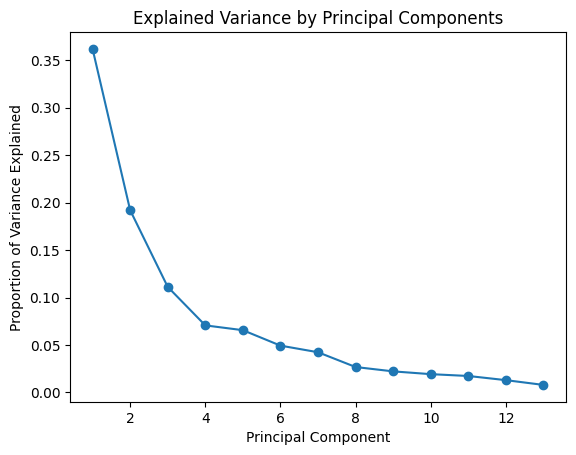

In [8]:
# Plot variance explained
plt.figure()
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Explained Variance by Principal Components")
plt.show()

In [9]:
# 5. PCA with 2 components (2D projection)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

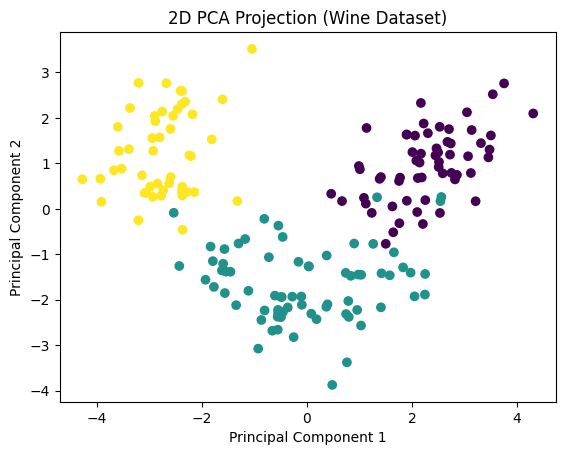

In [10]:
plt.figure()
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection (Wine Dataset)")
plt.show()

In [11]:
# 6. PCA with 3 components (3D projection)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

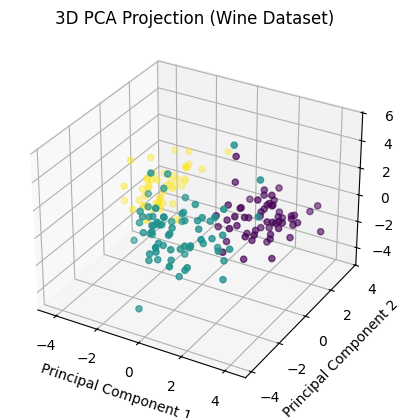

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Projection (Wine Dataset)")
plt.show()